# Demand Forecasting Notebook

This notebook validates the regression component of **AeroNet Pro / AeroNet Lite**. The goal is to predict delivery-demand intensity using time/weather-style features and report MAE, RMSE, and feature importance before integration into the Streamlit dashboard.

In [1]:
from pathlib import Path
import os
import sys

# This notebook is intended to be placed inside the notebooks/ folder.
# It automatically switches to the project root so imports and relative paths work.
cwd = Path.cwd()
if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
elif (cwd / "app.py").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "app.py").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

for folder in ["outputs", "report/figures", "data/processed"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\acer\Downloads\aeronet_pro\aeronet_pro


## 1. Import libraries and project ML function

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from ml_models import train_demand_model, load_bike_demand

## 2. Load demand dataset

The project function first looks for `data/raw/bike_train.csv`. If that file is not available, it creates a reproducible synthetic demand dataset so the notebook remains runnable during viva/demo.

In [3]:
df = load_bike_demand()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10886, 15)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,dayofweek,month
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,5,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,5,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,5,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,5,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,5,1


## 3. Train Random Forest Regressor

The model uses features such as season, holiday, working day, weather, temperature, humidity, wind speed, hour, day of week, and month to predict demand count.

In [4]:
demand_result = train_demand_model()

metrics = pd.DataFrame([{
    "model": "Random Forest Regressor",
    "MAE": demand_result["mae"],
    "RMSE": demand_result["rmse"],
    "Mean Predicted Demand": demand_result["mean_pred"]
}])

metrics

,model,MAE,RMSE,Mean Predicted Demand
0,Random Forest Regressor,44.021,65.805,192.179


## 4. Feature importance

The feature importance plot shows which variables contributed most to demand prediction. In the dashboard run, `hour` was the strongest feature, which is logically valid because delivery/order activity changes strongly across the day.

In [5]:
importance = demand_result["importance"].copy()
importance

,feature,importance
7,hour,0.610086
4,temp,0.135845
5,humidity,0.064262
2,workingday,0.047899
9,month,0.038603
8,dayofweek,0.036146
6,windspeed,0.030505
3,weather,0.020923
0,season,0.013736
1,holiday,0.001995


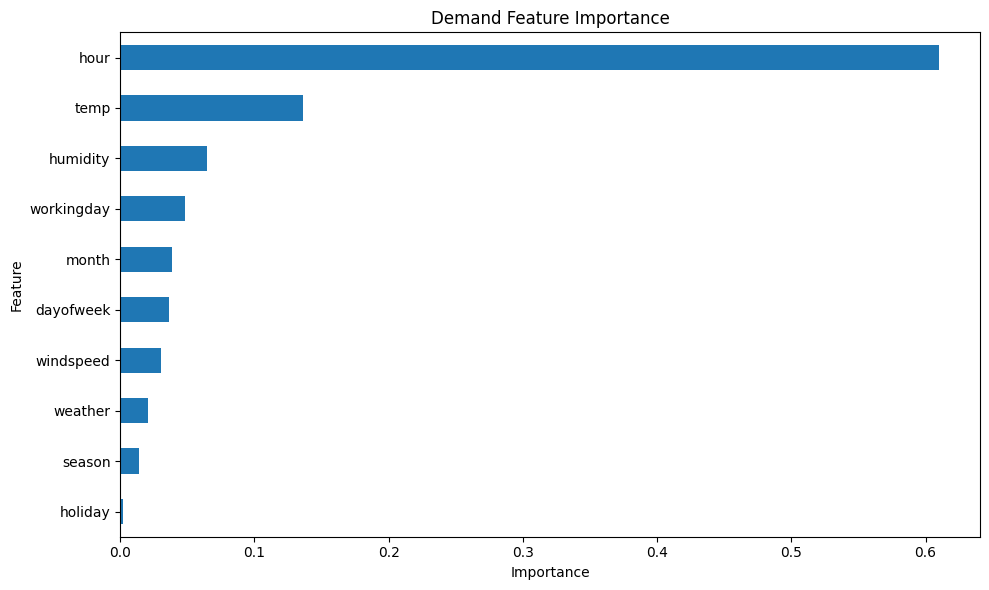

In [6]:
ax = importance.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 6),
    legend=False,
    title="Demand Feature Importance"
)
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("report/figures/notebook_demand_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Save notebook outputs

These CSV files can be submitted inside the `outputs/` folder and used as report evidence.

In [7]:
metrics.to_csv("outputs/demand_forecasting_metrics.csv", index=False)
importance.to_csv("outputs/demand_feature_importance.csv", index=False)

print("Saved:")
print("- outputs/demand_forecasting_metrics.csv")
print("- outputs/demand_feature_importance.csv")
print("- report/figures/notebook_demand_feature_importance.png")

Saved:
- outputs/demand_forecasting_metrics.csv
- outputs/demand_feature_importance.csv
- report/figures/notebook_demand_feature_importance.png


## 6. Short conclusion

The regression component successfully estimates delivery-demand intensity using structured temporal and weather-related features. The exported MAE/RMSE values and feature importance table are later integrated into the Streamlit dashboard and final report.